# impacts of corruption: development set

I'm using splits of `zh-plus/tiny-imagenet` on a subset of corruptions as a development set for adapatation questions.

locally generated in vision_model_benchmarks


In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.core.pylabtools import figsize

import seaborn as sns

import numpy as np
import pandas as pd

from tqdm import tqdm
import torch

## Initial probe training

### model classifier

In [2]:
from datasets import load_dataset
from src.model.setup import image_model_setup
from src.model.harness import TrainConfig

model_name = "facebook/dinov2-base"
train_set = load_dataset('datasets/tiny_imagenet/uncorrupted_train/', streaming=True)


model, image_datasets, _ = image_model_setup(model_name, None, 200, full_dataset=train_set)

train_cfg = TrainConfig(steps_per_epoch=1379, epochs=3)
model.train_cfg = train_cfg

W0313 08:57:54.831000 10887 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


import error: No module named 'triton'


Some weights of Dinov2ForImageClassification were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [3]:
from src.train.training import train_readout

dl_train = torch.utils.data.DataLoader(image_datasets['train'], batch_size=64, num_workers=1)
dl_val = torch.utils.data.DataLoader(image_datasets['validation'], batch_size=64, num_workers=1)

In [4]:
train_readout(model, dl_train, dl_val, 'devset/base')

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
wandb: Currently logged in as: lrast to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



  | Name                | Type                         | Params | Mode 
-----------------------------------------------------------------------------
0 | model               | Dinov2ForImageClassification | 86.9 M | eval 
1 | classification_loss | CrossEntropyLoss             | 0      | train
-----------------------------------------------------------------------------
307 K     Trainable params
86.6 M    Non-trainable params
86.9 M    Total params
347.552   Total estimated model params size (MB)
1         Modules in train mode
226       Modules in eval mode


Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

/Users/luke/.local/defaultPythonEnv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:419: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.
W0313 08:58:02.757000 10914 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
/Users/luke/.local/defaultPythonEnv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:419: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.
W0313 08:58:10.132000 10920 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Training: |                                               | 0/? [00:00<?, ?it/s]

...

W0313 09:35:02.563000 11269 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Validation: |                                             | 0/? [00:00<?, ?it/s]

import error: No module named 'triton'


Metric val/accuracy improved by 0.003 >= min_delta = 0.0. New best score: 0.867
`Trainer.fit` stopped: `max_epochs=3` reached.


debug/max,▁▄▅▅▅▆▆▆▇▇▆▇▇▇▇▇█▇▇█▇█▇▇▇▇█▆▇▆▆█▇▇▇▇▇▇█▆
debug/min,██▇█▇▆▅▅▄▄▄▃▄▃▄▃▃▄▄▃▃▂▃▃▃▁▂▂▃▃▃▃▃▃▂▂▂▄▁▃
epoch,▁▁▁▁▁▁▁▁▁▁▁▁▁▅▅▅▅▅▅▅▅▅▅▅▅▅██████████████
grad_inf_norm/model.classifier.bias,▇▅▄▅█▄▆▄█▇▄▇██▇▆▇█▄▄▄▄▄▅▅▄▄▅▂▄▄▂▁▃▁▄▂▃▄▄
grad_inf_norm/model.classifier.weight,▇▄▄▆▄▃▄▅█▄▅▄▅▃▃▄▄▃▄▅▆▃▄▄▃▂▄▃▁▃▂▁▂▂▃▂▂▂▃▃
grad_inf_norm_total,▇▆▃▄▄▄▄█▅█▅▄▅▃▄▄▄▅▃▃▄▅▃▃▃▃▄▂▅▄▃▃▄▂▁▂▃▁▂▃
lr-AdamW,▂▇████████▇▇▇▇▇▇▆▆▆▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁
train/loss,█▃▂▂▂▂▂▂▂▂▂▂▂▁▂▁▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▆▆▇▇▇▇██████
val/accuracy,▁▇█
+1,...


### internal classifiers 

In [4]:
from datasets import load_dataset
from src.model.setup import image_model_setup
from src.model.harness import TrainConfig
from src.model.CLS_token_probing import SimpleReadOutAttachment

model_name = "facebook/dinov2-base"
train_set = load_dataset('datasets/tiny_imagenet/uncorrupted_train/', streaming=True)

from src.train.training import train_readout

dl_train = torch.utils.data.DataLoader(image_datasets['train'], batch_size=64, num_workers=1)
dl_val = torch.utils.data.DataLoader(image_datasets['validation'], batch_size=64, num_workers=1)

In [5]:
for layer_num in range(8,12):
    model, image_datasets, _ = image_model_setup(model_name, None, 200, full_dataset=train_set)
    
    train_cfg = TrainConfig(steps_per_epoch=1379, epochs=3)
    model.train_cfg = train_cfg

    readout = SimpleReadOutAttachment(layer_num)
    model.add_readout(readout)
    
    train_readout(model, dl_train, dl_val, f'devset/readout{layer_num}')

Some weights of Dinov2ForImageClassification were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
wandb: Currently logged in as: lrast to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/Users/luke/.local/defaultPythonEnv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /Users/luke/Documents/activeProjects/CLStokenInformation/slow_temp_annealing_ckpt exists and is not empty.

  | Name                | Type                         | Params | Mode 
-----------------------------------------------------------------------------
0 | model               | Dinov2ForImageClassification | 86.9 M | eval 
1 | classification_loss | CrossEntropyLoss             | 0      | train
2 | readout             | SimpleReadOutAttachment      | 9.2 M  | train
-----------------------------------------------------------------------------
2.4 M     Trainable params
86.6 M    Non-trainable params
89.0 M    Total params
355.880   Total estimated model params size (MB)
15        Modules in train mode
226       Modules in eval mode


Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

/Users/luke/.local/defaultPythonEnv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:419: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.
W0313 09:40:48.545000 11323 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
/Users/luke/.local/defaultPythonEnv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:419: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.
W0313 09:40:55.538000 11325 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Training: |                                               | 0/? [00:00<?, ?it/s]

...

W0313 12:53:22.891000 13828 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Validation: |                                             | 0/? [00:00<?, ?it/s]

import error: No module named 'triton'


Metric val/accuracy improved by 0.010 >= min_delta = 0.0. New best score: 0.868
`Trainer.fit` stopped: `max_epochs=3` reached.


debug/max,▁▃▃▃▅▄▅▆▅▆▆▅▄▄▆▅█▇▆▅▆▆▇▇▅▅▆▇▆▆▆▇▆▆▇▆▆▆▆▇
debug/min,█▅▅▅▄▅▅▅▄▄▅▅▄▄▄▄▄▄▃▃▄▃▃▄▃▃▃▄▃▃▁▃▃▃▃▃▃▂▂▃
epoch,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▅▅▅▅▅▅▅▅▅▅▅▅▅▅████████████
grad_inf_norm/readout.decoder.cls_generator.mlp.0.bias,█▄▂▁▂▂▂▁▂▂▂▂▂▂▁▂▂▂▂▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁
grad_inf_norm/readout.decoder.cls_generator.mlp.0.weight,█▃▂▃▄▄▃▂▄▄▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▂▃▂▂▂▁▂▃▂▁▂▁▁▃▁
grad_inf_norm/readout.decoder.cls_generator.mlp.2.bias,▇▄▃▅▅▇▅▆▄▄▃▄▅█▅▆▄▅▄▅▄▆▄▂█▇▆▇▂▂▅▆▄▂▂▃▃▁▃▅
grad_inf_norm/readout.decoder.cls_generator.mlp.2.weight,█▁▂▂▂▁▂▂▂▁▂▂▂▂▃▃▃▂▂▂▂▂▁▁▁▂▂▁▄▂▂▁▁▁▂▁▁▁▂▁
grad_inf_norm/readout.decoder.cls_generator.mlp.4.bias,█▆▂▂▁▁▂▂▁▂▂▂▂▂▂▄▂▁▁▁▂▁▁▂▁▂▂▂▁▁▁▁▂▁▁▁▁▁▂▁
grad_inf_norm/readout.decoder.cls_generator.mlp.4.weight,█▂▂▁▁▁▂▁▂▃▁▃▂▂▄▃▂▁▂▄▁▂▂▃▂▃▃▂▄▂▃▂▄▂▂▁▂▁▂▂
grad_inf_norm/readout.decoder.cls_generator.mlp.6.bias,█▄▂▂▂▂▂▂▂▂▂▃▂▃▂▂▂▂▂▂▂▁▂▂▃▂▂▂▂▂▂▂▂▁▂▁▂▁▁▂
+9,...


## Analysis: readout consistency

Does the level of consistency between the readouts change with corruptions?

I'm using 'gaussian_noise', 'zoom_blur', 'pixelate', and 'brightness' as a development set of corruptions. I added brightness because pixelate is too minor.

In [2]:
from datasets import load_dataset
from src.model.setup import image_model_setup
from src.model.harness import TrainConfig
from src.model.CLS_token_probing import SimpleReadOutAttachment



import error: No module named 'triton'


W0325 10:54:35.772000 52842 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [3]:
# dataset loading and preprocessing
def load_and_process(corruption):
    model_name = "facebook/dinov2-base"
    
    test_set = load_dataset(f'datasets/tiny_imagenet/corrupted_{corruption}/', streaming=True)
    model, test_set, _ = image_model_setup(model_name, None, 200, full_dataset=test_set)

    return test_set

In [4]:
# loading models:
from safetensors import safe_open

def load_model_and_data(layer):
    """
    I still need to improve loading for readouts, this is the current approach...
    """
    model_name = "facebook/dinov2-base"
    model, _, _ = image_model_setup(model_name, 'zh-plus/tiny-imagenet' , 200)

    if layer is None or layer == 'None':
        raw = safe_open('devset/base/readout/model.safetensors', framework='pt')
        model.model.load_state_dict({key: raw.get_tensor(key) for key in raw.keys()}, strict=False )

    else:
        readout = SimpleReadOutAttachment.from_pretrained(f'devset/readout{layer}/readout')
        model.add_readout(readout)

    return model

### Accuracy analysis

In [5]:
results = []

for corruption in ['None', 'gaussian_noise', 'pixelate', 'zoom_blur', 'brightness']:
    for readout_layer in ['None', 8, 9, 10, 11]:
        dataset = load_and_process(corruption)['test']
        model = load_model_and_data(readout_layer)
        _ = model.to('mps')

        dl = torch.utils.data.DataLoader(dataset, batch_size=64)

        for batch_ind, batch in tqdm(enumerate(dl), total=157, desc=f"{corruption}, {readout_layer}"):
            start_ind = 64*batch_ind

            predictions = model.forward(batch['input'].to('mps')).cpu().argmax(1)
            targets = targets = batch['label']
            for i in range(len(targets)):
                results.append({'dataset': corruption, 'layer': readout_layer,
                                'prediction': predictions[i].item(), 'target': targets[i].item(),
                                'image_id': start_ind + i
                               })

        pd.DataFrame(results).to_csv('backup.csv', index=False)

Some weights of Dinov2ForImageClassification were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of Dinov2ForImageClassification were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
None, None: 100%|█████████████████████████████| 157/157 [01:37<00:00,  1.61it/s]
Some weights of Dinov2ForImageClassification were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of Dinov2ForImageClas

Loading weights from local directory


None, 8: 100%|████████████████████████████████| 157/157 [01:51<00:00,  1.41it/s]
Some weights of Dinov2ForImageClassification were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of Dinov2ForImageClassification were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading weights from local directory


None, 9: 100%|████████████████████████████████| 157/157 [01:48<00:00,  1.45it/s]
Some weights of Dinov2ForImageClassification were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of Dinov2ForImageClassification were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

brightness, 9: 100%|██████████████████████████| 157/157 [01:51<00:00,  1.40it/s]
Some weights of Dinov2ForImageClassification were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of Dinov2ForImageClassification were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading weights from local directory


brightness, 10: 100%|█████████████████████████| 157/157 [01:51<00:00,  1.40it/s]
Some weights of Dinov2ForImageClassification were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of Dinov2ForImageClassification were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading weights from local directory


brightness, 11: 100%|█████████████████████████| 157/157 [01:52<00:00,  1.39it/s]


In [6]:
results = pd.DataFrame(results)

In [7]:
results['correct'] = (results['prediction'] == results['target'])

In [8]:
results.groupby(['dataset', 'layer']).mean()

prediction  target  image_id  correct
dataset        layer                                       
None           8         99.1947    99.5    4999.5   0.6699
               9         99.5894    99.5    4999.5   0.7394
               10        99.4974    99.5    4999.5   0.7869
               11        99.6272    99.5    4999.5   0.8691
               None      99.7210    99.5    4999.5   0.8712
brightness     8         99.1910    99.5    4999.5   0.5669
               9        100.1303    99.5    4999.5   0.6459
               10       100.8707    99.5    4999.5   0.6964
               11       100.1110    99.5    4999.5   0.8037
               None     100.2704    99.5    4999.5   0.8015
gaussian_noise 8         91.0755    99.5    4999.5   0.3805
               9         95.9002    99.5    4999.5   0.4599
               10        95.3372    99.5    4999.5   0.5180
               11        96.5136    99.5    4999.5   0.6612
               None      96.3987    99.5    4999.5   0.6508
pixelate       8         98.8793    99.5    4999.5   0.6201
               9        100.0064    99.5    4999.5   0.6986
               10        99.5591    99.5    4999.5   0.7513
               11       100.1881    99.5    4999.5   0.8477
               None      99.8302    99.5    4999.5   0.8453
zoom_blur      8         99.2870    99.5    4999.5   0.1272
               9        108.7151    99.5    4999.5   0.2183
               10       106.4013    99.5    4999.5   0.2646
               11       106.8109    99.5    4999.5   0.3780
               None      97.8494    99.5    4999.5   0.3507

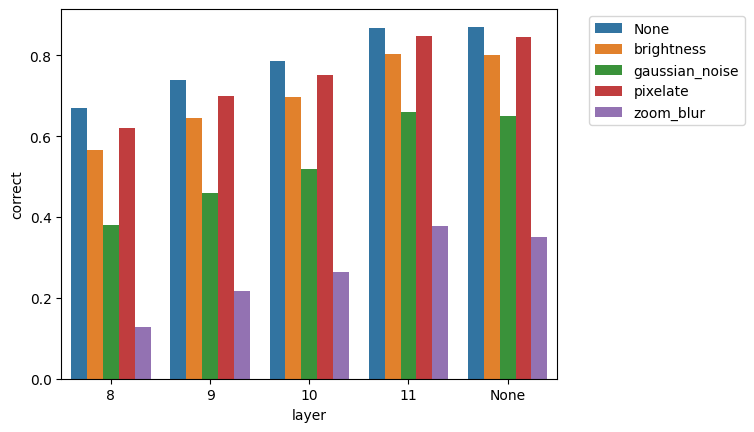

In [9]:
accuracies = results.groupby(['dataset', 'layer']).mean()['correct']
sns.barplot(accuracies.reset_index(),
            x='layer',
            y='correct',
            hue='dataset')
_=plt.legend(bbox_to_anchor=(1.05, 1))


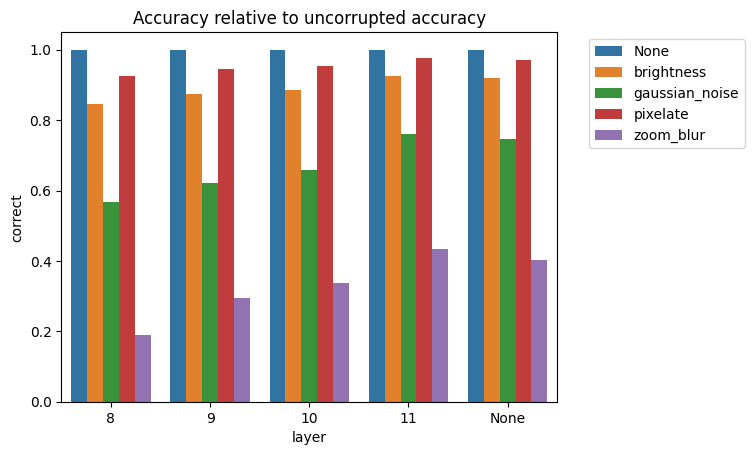

In [10]:
sns.barplot((accuracies / accuracies['None']).reset_index(),
            x='layer', y='correct', hue='dataset')
plt.legend(bbox_to_anchor=(1.05, 1))
_ = plt.title('Accuracy relative to uncorrupted accuracy')

1. pixelate noise has almost no effect: not surprising given that we've up-sized the images before adding noise
2. deeper layers are _more_ sensitive to corruption than higher layer.
   - this makes sense: the learned representations in these layers are less robust.


One question is agreement: do the internal and final read-out agree more when the answers are correct? Does this happen more often than randomly, given the statistics of the outputs?

In [11]:
results['correct'] = results['correct'].astype(int)

In [12]:
analysis = results.pivot(index=['dataset', 'image_id'], columns='layer', values=['prediction', 'correct', 'target'])

In [13]:
analysis

prediction                     correct                \
layer                       8    9   10   11 None       8  9 10 11 None   
dataset   image_id                                                        
None      0                56   56  117   56   56       1  1  0  1    1   
          1               156  118  156  103  103       0  0  0  0    0   
          2                47   48   44   48   48       0  1  0  1    1   
          3                80  109  145  145  145       0  0  1  1    1   
          4               193  193   96  195  195       0  0  0  1    1   
...                       ...  ...  ...  ...  ...     ... .. .. ..  ...   
zoom_blur 9995             58   59  156   58   58       1  0  0  1    1   
          9996            143  157   94  143  143       1  0  0  1    1   
          9997              9    9  190    3    3       0  0  0  1    1   
          9998              9   12   51   51   51       0  0  0  0    0   
          9999            156  156  156  156  156       1  1  1  1    1   

                   target                      
layer                   8    9   10   11 None  
dataset   image_id                             
None      0            56   56   56   56   56  
          1            58   58   58   58   58  
          2            48   48   48   48   48  
          3           145  145  145  145  145  
          4           195  195  195  195  195  
...                   ...  ...  ...  ...  ...  
zoom_blur 9995         58   58   58   58   58  
          9996        143  143  143  143  143  
          9997          3    3    3    3    3  
          9998         43   43   43   43   43  
          9999        156  156  156  156  156  

[50000 rows x 15 columns]

In [14]:
modes = analysis['prediction'].mode(axis=1)[0].astype(int)
mode_acc = (modes == analysis['target']['None']).unstack('dataset').mean()
output_acc = analysis['correct']['None'].unstack('dataset').mean()

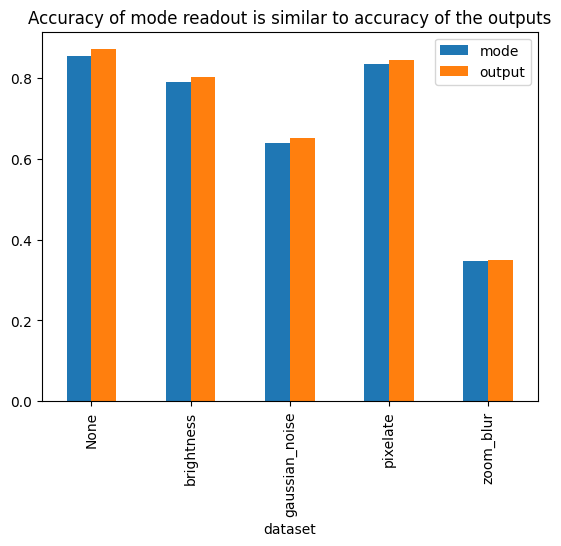

In [15]:
pd.DataFrame({'mode': mode_acc, 'output': output_acc}).plot.bar()
_=plt.title('Accuracy of mode readout is similar to accuracy of the outputs')

But consistently lower. This means that taking the modal output does not help with corruptions on its own.

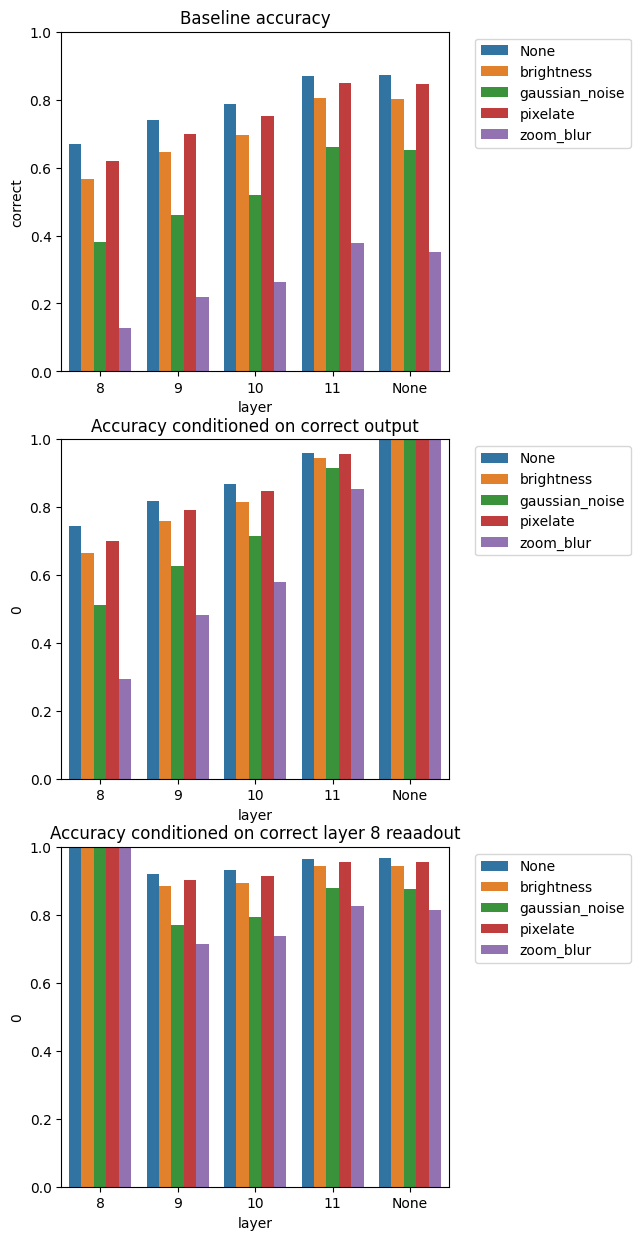

In [16]:
figsize(5, 15)
plt.subplots(3,1)

plt.subplot(3,1,1)
accuracies = results.groupby(['dataset', 'layer']).mean()['correct']
sns.barplot(accuracies.reset_index(),
            x='layer',
            y='correct',
            hue='dataset')
_=plt.legend(bbox_to_anchor=(1.05, 1))
plt.title('Baseline accuracy')
_=plt.ylim([0,1])


plt.subplot(3,1,2)
sns.barplot(
    analysis[analysis[('correct', 'None')] == 1]['correct'].unstack('dataset'
                                                               ).mean(
                                                               ).reset_index(
                                                               ),
    x='layer', y=0, hue='dataset')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.title('Accuracy conditioned on correct output')
_=plt.ylim([0,1])

plt.subplot(3,1,3)
sns.barplot(
    analysis[analysis[('correct', 8)] == 1]['correct'].unstack('dataset'
                                                               ).mean(
                                                               ).reset_index(
                                                               ),
    x='layer', y=0, hue='dataset')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.title('Accuracy conditioned on correct layer 8 reaadout')
_=plt.ylim([0,1])

Both of these conditionings are helpful, implying that correct answers over-lap more often than not. Layer 8 conditioning being more helpful than correct conditioning seems to imply a heirarchy: images with layer 8 correct are (mostly) a subset of images with correct outputs.

To summarize, agreement is good, but not enough to see mode improvement. At the same time, the _worse_ performance of lower layer readouts leaves something to be desired: how can they be good a 'steering' the representation if they are less accuracy?